In [ ]:
# 6 strategies, used StraightForceToColony to see if results are different

# adding ApplyColonyPullingForce() to informed as 5 but more runs
# run on maze more time than 7 200 ants detchafter 4f to 10f 	float colonyPullStrength = 4.0f

#same as 9 20  runs

In [3]:
from sim_tools import run_simulation, SimulationParameters
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

In [4]:
num_sim = 20
steering_strategies = 6

use_pher = [i for i in range(steering_strategies*num_sim)]

batch_results2 = [(run_simulation(SimulationParameters(usePheromoneSteering=pher % steering_strategies), headless=True), pher % steering_strategies)
                 for pher in tqdm(use_pher)]

100%|██████████| 120/120 [1:29:15<00:00, 44.63s/it]


In [6]:
Steering_names = [
    "home",
    "circle",
    "gradient",
    "gaussian",
    "Inverse Square",
    "Exponential",
]

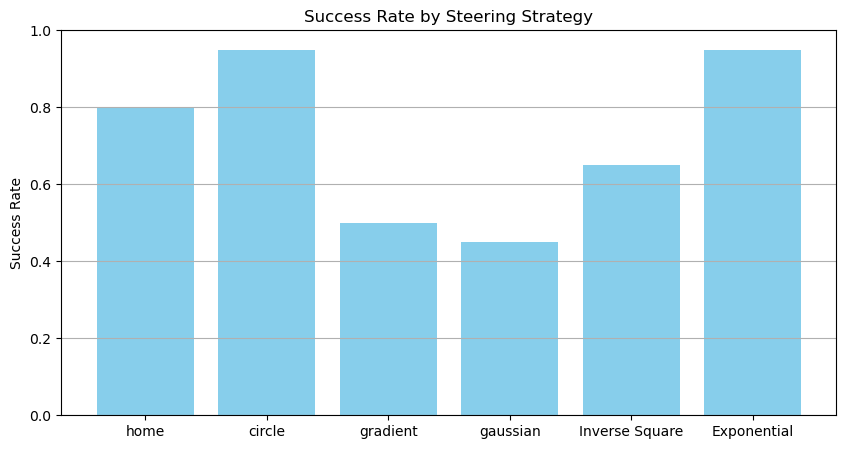

home: Success Rate=80.00% (16/20)
circle: Success Rate=95.00% (19/20)
gradient: Success Rate=50.00% (10/20)
gaussian: Success Rate=45.00% (9/20)
Inverse Square: Success Rate=65.00% (13/20)
Exponential: Success Rate=95.00% (19/20)


In [7]:
def plot_success_rates(batch_results, num_strategies=6, strategy_names=None):
    # Count successes for each strategy
    success_counts = [0] * num_strategies
    total_counts = [0] * num_strategies

    for res, strategy in batch_results:
        if 0 <= strategy < num_strategies:
            total_counts[strategy] += 1
            if res and getattr(res, "didSucceed", False):
                success_counts[strategy] += 1

    # Calculate success rates
    success_rates = [
        (success_counts[i] / total_counts[i]) if total_counts[i] else 0
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(range(num_strategies), success_rates,
            tick_label=labels, color='skyblue')
    plt.ylabel("Success Rate")
    plt.title("Success Rate by Steering Strategy")
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Success Rate={success_rates[i]:.2%} ({success_counts[i]}/{total_counts[i]})")


plot_success_rates(batch_results2, steering_strategies, Steering_names)

In [8]:
# print results
def print_results(batch_results):
    for res, ss in batch_results:
        if res:
            print(
                f"Run (usePheromoneSteering={ss}): Success, duration={res.duration}, success={res.didSucceed}")
        else:
            print(f"Run (usePheromoneSteering={ss}): Failed")                      

In [9]:
print_results(batch_results2)

Run (usePheromoneSteering=0): Success, duration=381.6851806640625, success=True
Run (usePheromoneSteering=1): Success, duration=730.5252685546875, success=True
Run (usePheromoneSteering=2): Success, duration=5000.0009765625, success=False
Run (usePheromoneSteering=3): Success, duration=726.204345703125, success=True
Run (usePheromoneSteering=4): Success, duration=628.258544921875, success=True
Run (usePheromoneSteering=5): Success, duration=1099.4503173828125, success=True
Run (usePheromoneSteering=0): Success, duration=674.6944580078125, success=True
Run (usePheromoneSteering=1): Success, duration=510.7359619140625, success=True
Run (usePheromoneSteering=2): Success, duration=5000.0576171875, success=False
Run (usePheromoneSteering=3): Success, duration=5000.03759765625, success=False
Run (usePheromoneSteering=4): Success, duration=5000.0771484375, success=False
Run (usePheromoneSteering=5): Success, duration=812.3231201171875, success=True
Run (usePheromoneSteering=0): Success, durat

In [10]:
import matplotlib.pyplot as plt


def plot_torus_positions_by_strategy(batch_results, strategy_names=None):
    """
    Plots the torus positions for each strategy in separate graphs.
    Each plot shows the paths for all successful runs of that strategy.
    """
    num_strategies = max(pher for _, pher in batch_results) + 1
    if strategy_names is None:
        strategy_names = [f"Steering={i}" for i in range(num_strategies)]

    for strategy in range(num_strategies):
        # Collect all successful torus positions for this strategy
        paths = [
            res.torusPositions for res, pher in batch_results
            if pher == strategy and res and hasattr(res, "torusPositions") and res.didSucceed
        ]
        if not paths:
            continue  # Skip if no successful runs

        plt.figure(figsize=(6, 6))
        for path in paths:
            xs = [p.x for p in path]
            ys = [p.y for p in path]
            plt.plot(xs, ys, alpha=0.5)
        plt.title(f"Torus Paths - {strategy_names[strategy]}")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid(True)
        plt.axis("equal")
        plt.show()

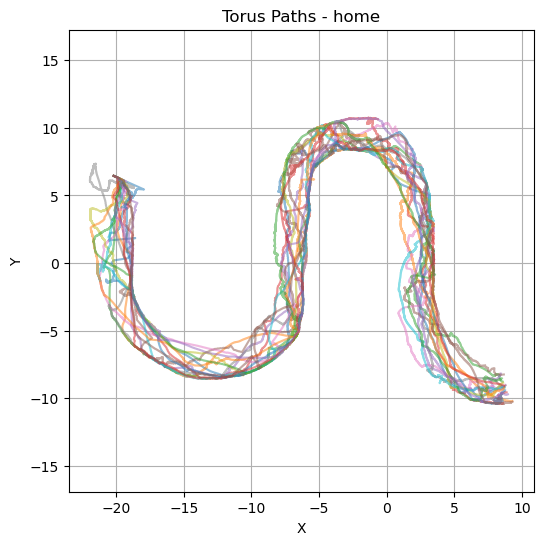

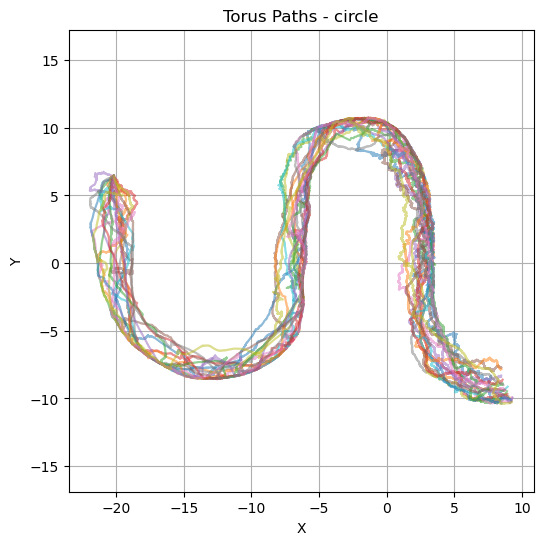

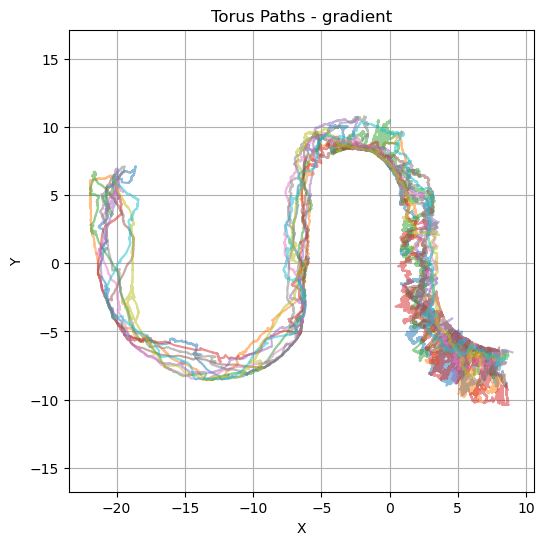

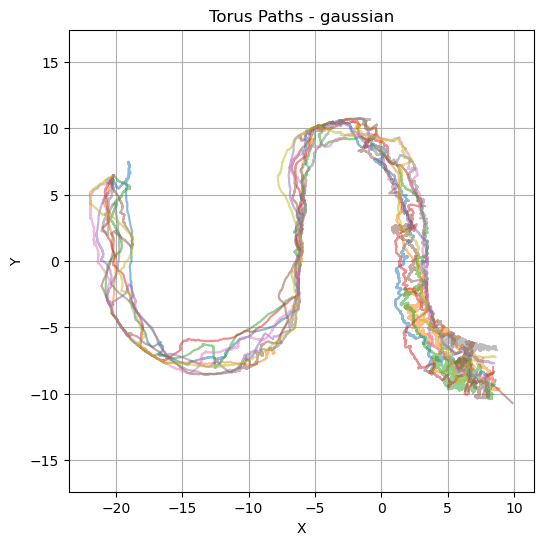

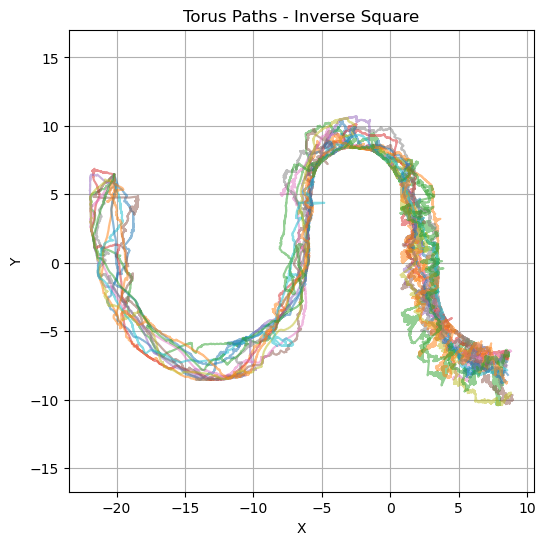

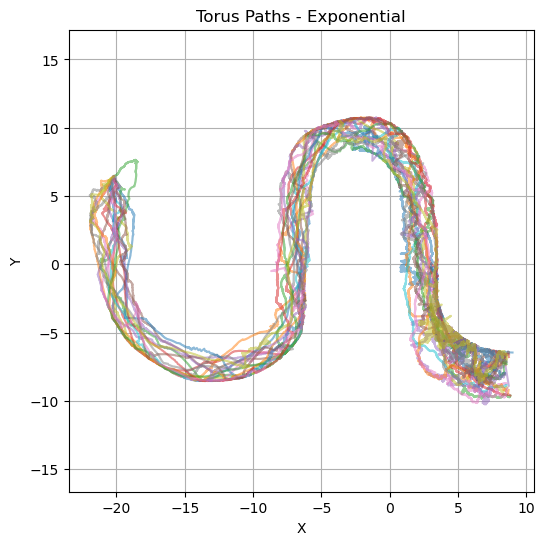

In [11]:
plot_torus_positions_by_strategy(batch_results2, Steering_names)

In [12]:
import matplotlib.pyplot as plt
import numpy as np


def plot_duration_comparison(batch_results, strategy_names=None):
    """
    Plots a boxplot comparing the durations (time to win) for each strategy.
    Only successful runs are included.
    """
    # Determine number of strategies
    num_strategies = max(pher for _, pher in batch_results) + 1

    # Collect durations for each strategy
    durations_by_strategy = [[] for _ in range(num_strategies)]
    for res, strategy in batch_results:
        if res and getattr(res, "didSucceed", False):
            durations_by_strategy[strategy].append(res.duration)

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot boxplot
    plt.figure(figsize=(10, 6))
    plt.boxplot(durations_by_strategy, tick_labels=labels)
    plt.ylabel("Duration (seconds)")
    plt.title("Time to Win by Strategy (Successful Runs Only)")
    plt.grid(True)
    plt.show()

    # Print average duration for each strategy
    for i in range(num_strategies):
        avg = np.mean(
            durations_by_strategy[i]) if durations_by_strategy[i] else float('nan')
        print(f"{labels[i]}: Average Duration = {avg:.2f} seconds")

# Example usage:

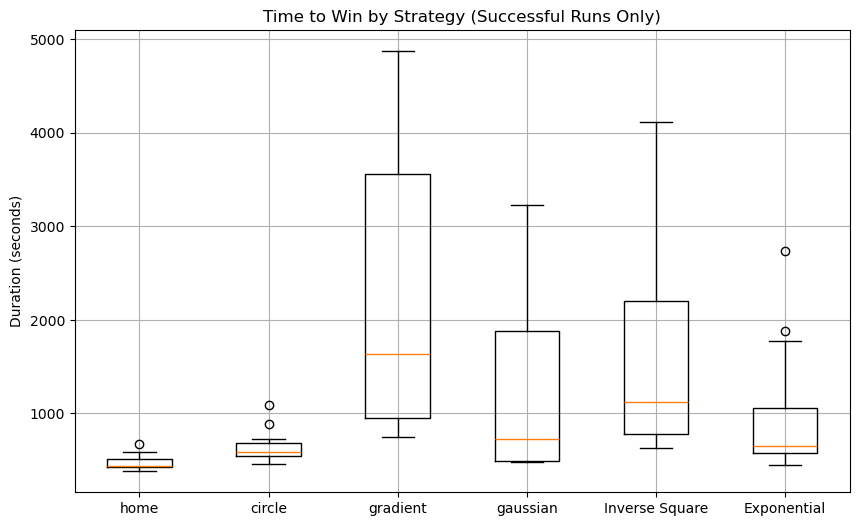

home: Average Duration = 472.25 seconds
circle: Average Duration = 636.81 seconds
gradient: Average Duration = 2243.59 seconds
gaussian: Average Duration = 1290.05 seconds
Inverse Square: Average Duration = 1663.59 seconds
Exponential: Average Duration = 935.79 seconds


In [13]:
plot_duration_comparison(batch_results2, Steering_names)

In [14]:
import matplotlib.pyplot as plt
import numpy as np


def compute_path_length(points):
    """Compute total path length from a list of Point objects with x, y attributes."""
    if not points or len(points) < 2:
        return 0
    return sum(
        np.linalg.norm([points[i+1].x - points[i].x,
                       points[i+1].y - points[i].y])
        for i in range(len(points)-1)
    )


def plot_path_length_comparison(batch_results, strategy_names=None):
    """
    Plots a boxplot comparing the total path length for each strategy.
    Only successful runs are included.
    """
    # Determine number of strategies
    num_strategies = max(pher for _, pher in batch_results) + 1

    # Collect path lengths for each strategy
    path_lengths_by_strategy = [[] for _ in range(num_strategies)]
    for res, strategy in batch_results:
        if res and getattr(res, "didSucceed", False) and hasattr(res, "torusPositions"):
            path_length = compute_path_length(res.torusPositions)
            path_lengths_by_strategy[strategy].append(path_length)

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot boxplot
    plt.figure(figsize=(10, 6))
    plt.boxplot(path_lengths_by_strategy, tick_labels=labels)
    plt.ylabel("Total Path Length")
    plt.title("Torus Path Length by Strategy (Successful Runs Only)")
    plt.grid(True)
    plt.show()

    # Print average path length for each strategy
    for i in range(num_strategies):
        avg = np.mean(
            path_lengths_by_strategy[i]) if path_lengths_by_strategy[i] else float('nan')
        print(f"{labels[i]}: Average Path Length = {avg:.2f}")

# Example usage:

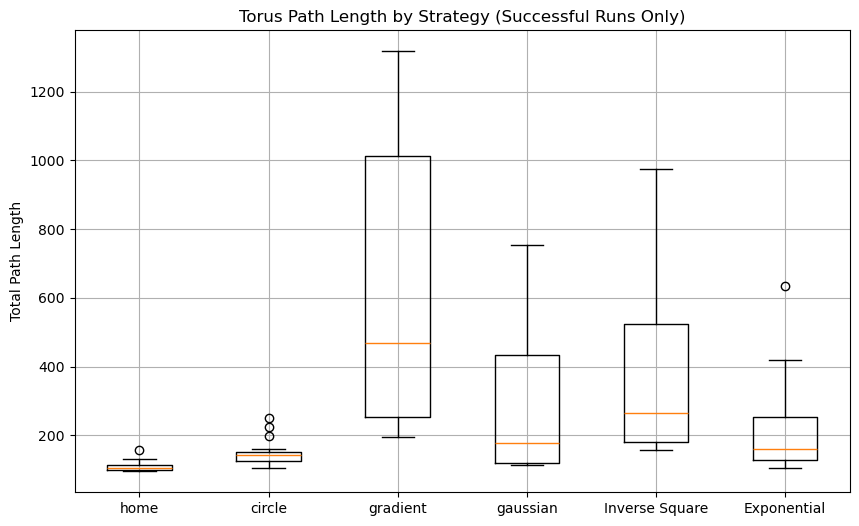

home: Average Path Length = 110.32
circle: Average Path Length = 149.06
gradient: Average Path Length = 623.72
gaussian: Average Path Length = 302.01
Inverse Square: Average Path Length = 397.17
Exponential: Average Path Length = 220.17


In [15]:
plot_path_length_comparison(batch_results2, Steering_names)

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def compute_average_turning_angle(points):
    """Compute the average turning angle (in degrees) for a path of Point objects."""
    if not points or len(points) < 3:
        return 0
    angles = []
    for i in range(1, len(points)-1):
        v1 = np.array([points[i].x - points[i-1].x,
                      points[i].y - points[i-1].y])
        v2 = np.array([points[i+1].x - points[i].x,
                      points[i+1].y - points[i].y])
        if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0:
            continue
        cos_angle = np.clip(
            np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1, 1)
        angle = np.arccos(cos_angle)
        angles.append(np.degrees(angle))
    return np.mean(angles) if angles else 0


def plot_smoothness_comparison(batch_results, strategy_names=None):
    """
    Plots a bar chart comparing the average turning angle (smoothness) for each strategy.
    Only successful runs are included.
    """
    num_strategies = max(pher for _, pher in batch_results) + 1
    smoothness_by_strategy = [[] for _ in range(num_strategies)]
    for res, strategy in batch_results:
        if res and getattr(res, "didSucceed", False) and hasattr(res, "torusPositions"):
            avg_angle = compute_average_turning_angle(res.torusPositions)
            smoothness_by_strategy[strategy].append(avg_angle)

    # Compute mean smoothness for each strategy
    mean_smoothness = [
        np.mean(smoothness_by_strategy[i]) if smoothness_by_strategy[i] else float(
            'nan')
        for i in range(num_strategies)
    ]

    # Prepare labels
    if strategy_names is None:
        labels = [f"Steering={i}" for i in range(num_strategies)]
    else:
        labels = [strategy_names[i] if i < len(
            strategy_names) else f"Steering={i}" for i in range(num_strategies)]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(range(num_strategies), mean_smoothness,
            tick_label=labels, color='purple')
    plt.ylabel("Average Turning Angle (degrees)")
    plt.title("Route Smoothness by Strategy (Lower is Smoother)")
    plt.grid(axis='y')
    plt.show()

    # Print summary
    for i in range(num_strategies):
        print(
            f"{labels[i]}: Average Turning Angle = {mean_smoothness[i]:.2f}°")

# Example usage:
# plot_smoothness_comparison(batch_results2, Steering_names)

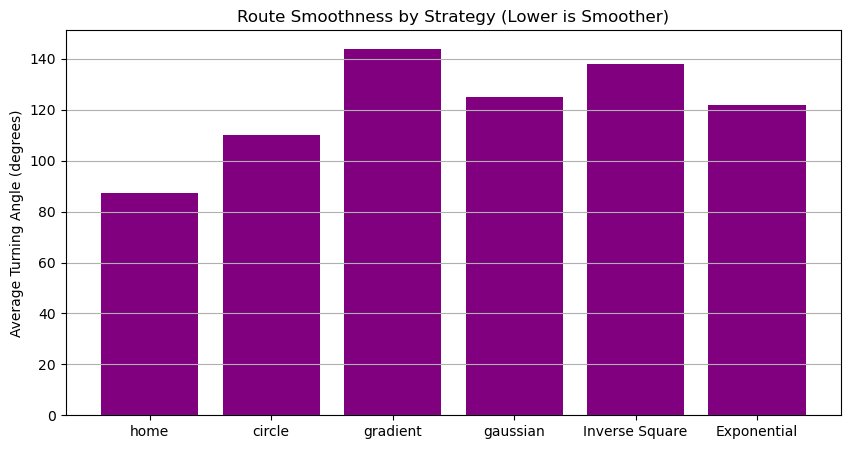

home: Average Turning Angle = 87.19°
circle: Average Turning Angle = 109.97°
gradient: Average Turning Angle = 144.03°
gaussian: Average Turning Angle = 124.98°
Inverse Square: Average Turning Angle = 137.94°
Exponential: Average Turning Angle = 121.75°


In [17]:
plot_smoothness_comparison(batch_results2, Steering_names)

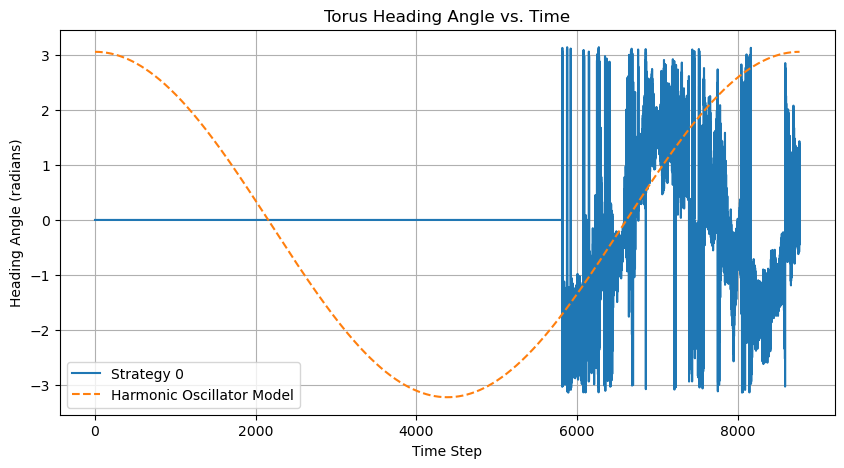

In [18]:
import numpy as np
import matplotlib.pyplot as plt


def compute_heading_angles(points):
    """Returns a list of heading angles (in radians) for a path of Point objects."""
    if not points or len(points) < 2:
        return []
    angles = []
    for i in range(1, len(points)):
        dx = points[i].x - points[i-1].x
        dy = points[i].y - points[i-1].y
        angle = np.arctan2(dy, dx)
        angles.append(angle)
    return angles


def plot_angle_vs_time_with_oscillator(res, label="Simulation"):
    if not res or not hasattr(res, "torusPositions") or len(res.torusPositions) < 2:
        print("No valid torus path.")
        return

    # Compute heading angles
    angles = compute_heading_angles(res.torusPositions)
    times = np.arange(len(angles))  # Assuming constant time step

    # Harmonic oscillator model (fit frequency/amplitude as needed)
    amplitude = (max(angles) - min(angles)) / 2 if angles else 1
    omega = 2 * np.pi / len(angles) if len(angles) > 0 else 1
    phase = 0
    oscillator = amplitude * np.cos(omega * times + phase) + np.mean(angles)

    plt.figure(figsize=(10, 5))
    plt.plot(times, angles, label=label)
    plt.plot(times, oscillator, '--', label="Harmonic Oscillator Model")
    plt.xlabel("Time Step")
    plt.ylabel("Heading Angle (radians)")
    plt.title("Torus Heading Angle vs. Time")
    plt.legend()
    plt.grid(True)
    plt.show()


# Example usage for the first successful run in batch_results2:
for res, strategy in batch_results2:
    if res and getattr(res, "didSucceed", False):
        plot_angle_vs_time_with_oscillator(res, label=f"Strategy {strategy}")
        break  # Remove break to plot for all

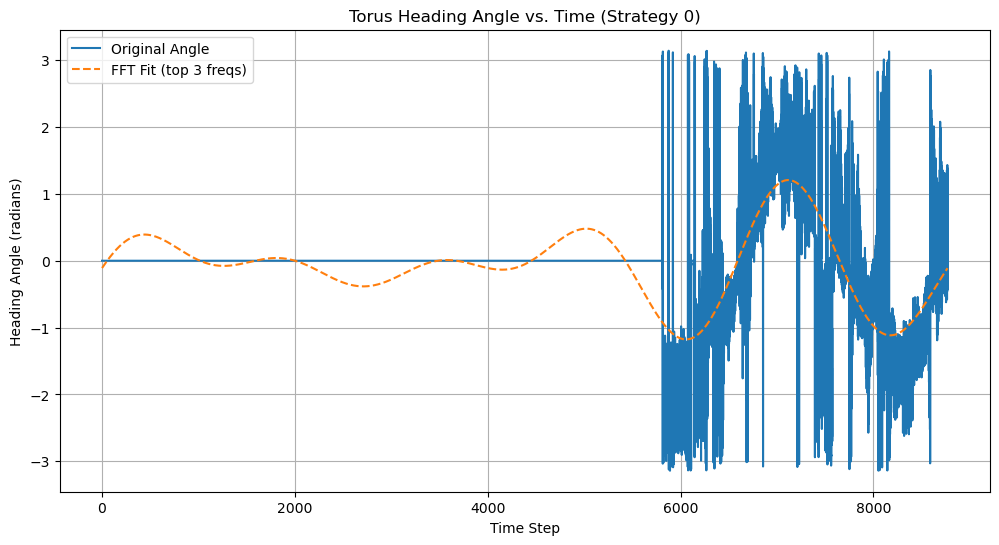

TypeError: stem() got an unexpected keyword argument 'use_line_collection'

<Figure size 1000x400 with 0 Axes>

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq, irfft


def compute_heading_angles(points):
    """Returns a list of heading angles (in radians) for a path of Point objects."""
    if not points or len(points) < 2:
        return []
    angles = []
    for i in range(1, len(points)):
        dx = points[i].x - points[i-1].x
        dy = points[i].y - points[i-1].y
        angle = np.arctan2(dy, dx)
        angles.append(angle)
    return angles


def plot_angle_fft_fit(res, label="Simulation", keep_n_freqs=3):
    if not res or not hasattr(res, "torusPositions") or len(res.torusPositions) < 2:
        print("No valid torus path.")
        return

    # Compute heading angles
    angles = compute_heading_angles(res.torusPositions)
    times = np.arange(len(angles))  # Assuming constant time step

    # Remove mean to focus on oscillatory part
    angles_centered = np.array(angles) - np.mean(angles)

    # FFT
    yf = rfft(angles_centered)
    xf = rfftfreq(len(angles_centered), d=1)

    # Keep only the largest N frequencies (excluding DC)
    idx = np.argsort(np.abs(yf[1:]))[::-1][:keep_n_freqs] + 1  # skip DC
    yf_filtered = np.zeros_like(yf)
    yf_filtered[0] = yf[0]  # keep DC
    yf_filtered[idx] = yf[idx]

    # Inverse FFT to get best fit
    fit = irfft(yf_filtered, n=len(angles_centered)) + np.mean(angles)

    # Plot original and fit
    plt.figure(figsize=(12, 6))
    plt.plot(times, angles, label="Original Angle")
    plt.plot(times, fit, '--', label=f"FFT Fit (top {keep_n_freqs} freqs)")
    plt.xlabel("Time Step")
    plt.ylabel("Heading Angle (radians)")
    plt.title(f"Torus Heading Angle vs. Time ({label})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Optional: Plot FFT spectrum
    plt.figure(figsize=(10, 4))
    plt.stem(xf, np.abs(yf), use_line_collection=True)
    plt.title("FFT Spectrum of Heading Angle")
    plt.xlabel("Frequency")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()


# Example usage for the first successful run in batch_results2:
for res, strategy in batch_results2:
    if res and getattr(res, "didSucceed", False):
        plot_angle_fft_fit(res, label=f"Strategy {strategy}", keep_n_freqs=3)
        break  # Remove break to plot for all